In [17]:
import numpy as np
import matplotlib.pyplot as plt
import math
# библиотека на основе которой были сделаны графики
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/layouts.html
from bokeh.layouts import column
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
# Активируем вывод графиков в ноутбук
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 32  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
W1_A = 1.0  # Амплитуда дополнительной волны 1
W2_A = 1.0  # Амплитуда дополнительной волны 2
W3_A = 1.0  # Амплитуда дополнительной волны 3
W4_A = 1.0  # Амплитуда дополнительной волны 4

# Фазы сигналов в градусах:
W1_P_DEG = 0   # Фаза дополнительной волны 1
W2_P_DEG = 0   # Фаза дополнительной волны 2
W3_P_DEG = 0   # Фаза дополнительной волны 3
W4_P_DEG = 0   # Фаза дополнительной волны 4

# Количество периодов сигнала (K):
W1_K = 7.503  # Дополнительная волна 1
W2_K = 0  # Дополнительная волна 2
W3_K = 0  # Дополнительная волна 3
W4_K = 0  # Дополнительная волна 4

# ----------------------------
# ПОДГОТОВКА ДАННЫХ
# ----------------------------

# Создаем массив отсчетов (от 0 до N-1)
N_i = np.arange(N)  # [0, 1, 2, ..., N-1]
# N_i_half = np.arange(N // 2 + 1)

# Конвертация фаз из градусов в радианы (требуется для тригонометрических функций)
W1_P_RAD = W1_P_DEG * np.pi / 180 # Формула преобразования: радианы = градусы * π/180
W2_P_RAD = W2_P_DEG * np.pi / 180
W3_P_RAD = W3_P_DEG * np.pi / 180
W4_P_RAD = W4_P_DEG * np.pi / 180

# ----------------------------
# ГЕНЕРАЦИЯ СИГНАЛОВ
# ----------------------------

# Генерация синусоиды:
# Формула: A * sin(2π * K * n/N + φ)
#   K - количество периодов
#   n - текущий отсчет
#   N - общее количество отсчетов
#   φ - фаза в радианах

# Используем sin вместо cos, но с фазой, отличающейся на π/2
# (cos(x) = sin(x + π/2), но здесь фаза задается параметром)
# Генерация  волн:
wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
wave_2 = W2_A * np.sin(2 * np.pi * W2_K * N_i / N + W2_P_RAD)
wave_3 = W3_A * np.sin(2 * np.pi * W3_K * N_i / N + W3_P_RAD)
wave_4 = W4_A * np.sin(2 * np.pi * W4_K * N_i / N + W4_P_RAD)

# ----------------------------
# СУММИРОВАНИЕ СИГНАЛОВ
# ----------------------------

# Сумма сгенерированных сигналов, в зависимости от примера количество сигналов может быть больше или меньше.
sum_wave = wave_1 + wave_2 + wave_3 + wave_4
# sum_wave = wave_1

# Произвести анализ частотного базиса. С выводом данных о нем.
F_b = 1
# DFT (прямое преобразование Фурье)
REX = np.zeros(N)
IMX = np.zeros(N)
PHASE = np.zeros(N)
MAG =  np.zeros(N)
phase_k = np.zeros(N) 
mag_k =  np.zeros(N)
sin_k = np.zeros(N)
cos_k = np.zeros(N)
for K in range(N):
    for I in range(N):
        angle = 2 * np.pi * K * I / N
        REX[K] += sum_wave[I] * np.cos(angle)
        IMX[K] -= sum_wave[I] * np.sin(angle)
        if I == N-1 :
          if REX[K] == 0:
            PHASE[K] = np.arctan(IMX[K] / 1e-20) * 180 / np.pi  
          else:
            PHASE[K] = np.arctan(IMX[K] / REX[K]) * 180 / np.pi  
            
          MAG[K] = np.sqrt(REX[I]**2 + IMX[I]**2)  
        if K == F_b:
            cos_k[I] = np.cos(angle)
            sin_k[I] = np.sin(angle)

            if REX[I] == 0:
              phase_k[I] = np.arctan(IMX[I] / 1e-20)  
            else:
              phase_k[I] = np.arctan(IMX[I] / REX[I])  
                
            mag_k[I] =  np.sqrt(REX[I]**2 + IMX[I]**2)  
            # sinus[I] =        np.sin(angle)
            # Форматирование значений для выравнивания
            k_str = f"K = {K}"
            i_str = f"I = {I}"
            imx_str = f"IMX[K] = {IMX[K]:.5f}"
            rex_str = f"REX[K] = {REX[K]:.5f}"
            xx_str = f"sum[I] = {sum_wave[I]:.5f}"
            sin_str = f"np.sin(angle) = {np.sin(angle):.5f}"
            cos_str = f"np.cos(angle) = {np.cos(angle):.5f}"
            angle_str = f"angle = {(180 * angle / 3.14) % 360:.2f}°"
            # angle_str = f"{angle:.2f}"
            
            # Вывод с фиксированной шириной колонок
            print(f"{k_str:<8}{i_str:<8}{imx_str:<20}{rex_str:<20}{xx_str:<20}{sin_str:<25}{cos_str:<25}{angle_str:<5}")
print("Амплитудный и фазовый спектры = " + str(np.sqrt(REX**2 + IMX**2)))

# Амплитудный и фазовый спектры
amplitude_spectrum = np.sqrt(REX**2 + IMX**2)

# Добавляем пороговое значение для обработки малых величин
ZERO_THRESHOLD = 1e-10  # Пороговое значение для обработки близких к нулю величин
phase_spectrum = np.zeros(N )
# phase_spectrum = np.arctan2(IMX, REX)
for i in range(len(REX)):
    amplitude_spectrum[i] = np.sqrt(REX[i]**2 + IMX[i]**2)
    
    if abs(REX[i]) < ZERO_THRESHOLD:
        REX[i] = 1e-20
    if abs(IMX[i]) < ZERO_THRESHOLD:
        IMX[i] = 0
        # Вычисление фазы с помощью math.atan
    phase_spectrum[i] = math.atan(IMX[i] / REX[i])
        
        # Ручная коррекция квадрантов (необходима при использовании math.atan)
    if REX[i] < 0 and IMX[i] < 0:
        phase_spectrum[i] = phase_spectrum[i] - math.pi
    elif REX[i] < 0 and IMX[i] >= 0:
        phase_spectrum[i] = phase_spectrum[i] + math.pi
    phase_spectrum[i] *= (180/math.pi)

print("PHASE = " + str(PHASE))
# ----------------------------
# ВИЗУАЛИЗАЦИЯ
# ----------------------------
# Используйте figure()функцию для построения графика. Передайте следующие аргументы:
# title: название вашей линейной диаграммы (необязательно)
# x_axis_label: текстовая метка для размещения на оси X диаграммы (необязательно)
# y_axis_label: текстовая метка для размещения на оси Y диаграммы (необязательно)

# создайте новый график с заголовком и метками осей
X_axis = np.zeros(N)
p = figure(title="Две снусоиды с одинаковой частотой и начальной фазой ", x_axis_label='Отсчеты', y_axis_label='Амплитуда')

# # Первая синусоида (y = sin(x))
p.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", line_color="blue", fill_alpha=0.3)
p.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")

p.scatter(N_i, sin_k, size=7, marker="square", legend_label="sin_k", line_color="green", fill_alpha=0.3)
p.line(N_i, sin_k, legend_label="sin_k", line_color="green")
p.line(N_i, X_axis, line_color="black")

show(p) 

amp_plot = figure(title="Спект частот ", x_axis_label='Частота', y_axis_label='Амплитуда')
p.line(N_i, amplitude_spectrum, legend_label="sum_wave", line_color="blue")

# X_axis = np.zeros(N + 1)
amp_plot.line(N_i, X_axis, line_color="black")

amp_plot.circle(N_i, amplitude_spectrum, size=8, color="navy", alpha=0.7)
amp_plot.segment(x0 = N_i, y0 = X_axis, x1=N_i, y1=amplitude_spectrum, color="navy", alpha=0.6, line_width=2)

show(amp_plot) 

phase_plot = figure(title="фаза ", x_axis_label='Частота', y_axis_label='Амплитуда')
phase_plot.line(N_i, PHASE, legend_label="PHASE", line_color="blue")

phase_plot.line(N_i, X_axis, line_color="black")

phase_plot.circle(N_i, PHASE, size=8, color="navy", alpha=0.7)
phase_plot.segment(x0 = N_i, y0 = X_axis, x1=N_i, y1=PHASE, color="navy", alpha=0.6, line_width=2)

show(phase_plot)

mag_plot = figure(title="амплитуда ", x_axis_label='Частота', y_axis_label='Амплитуда')
mag_plot.line(N_i, MAG, legend_label="MAG", line_color="blue")

mag_plot.line(N_i, X_axis, line_color="black")

mag_plot.circle(N_i, MAG, size=8, color="navy", alpha=0.7)
mag_plot.segment(x0 = N_i, y0 = X_axis, x1=N_i, y1=PHASE, color="navy", alpha=0.6, line_width=2)

show(mag_plot)

Loading BokehJS ...

K = 1   I = 0   IMX[K] = 0.00000    REX[K] = 0.00000    sum[I] = 0.00000    np.sin(angle) = 0.00000  np.cos(angle) = 1.00000  angle = 0.00°
K = 1   I = 1   IMX[K] = -0.19416   REX[K] = 0.97612    sum[I] = 0.99524    np.sin(angle) = 0.19509  np.cos(angle) = 0.98079  angle = 11.26°
K = 1   I = 2   IMX[K] = -0.26838   REX[K] = 1.15529    sum[I] = 0.19393    np.sin(angle) = 0.38268  np.cos(angle) = 0.92388  angle = 22.51°
K = 1   I = 3   IMX[K] = 0.26355    REX[K] = 0.35920    sum[I] = -0.95745   np.sin(angle) = 0.55557  np.cos(angle) = 0.83147  angle = 33.77°
K = 1   I = 4   IMX[K] = 0.53261    REX[K] = 0.09014    sum[I] = -0.38051   np.sin(angle) = 0.70711  np.cos(angle) = 0.70711  angle = 45.02°
K = 1   I = 5   IMX[K] = -0.20183   REX[K] = 0.58088    sum[I] = 0.88331    np.sin(angle) = 0.83147  np.cos(angle) = 0.55557  angle = 56.28°
K = 1   I = 6   IMX[K] = -0.71239   REX[K] = 0.79236    sum[I] = 0.55263    np.sin(angle) = 0.92388  np.cos(angle) = 0.38268  angle = 67.53°
K = 1   I = 7 

In [43]:
import numpy as np

# ПЕРЕХОД ОТ ПРЯМОУГОЛЬНОЙ ФОРМЫ К ПОЛЯРНОЙ И ОТ ПОЛЯРНОЙ К ПРЯМОУГОЛЬНОЙ

# Массивы для хранения данных
REX = np.zeros(257)  # Массив REX содержит действительную часть (индексы 0-256)
IMX = np.zeros(257)  # Массив IMX содержит мнимую часть
MAG = np.zeros(257)  # Массив MAG содержит модуль
PHASE = np.zeros(257)  # Массив PHASE содержит фазу

PI = 3.14159265

# Вместо подпрограммы загрузки данных инициализируем массивы примерными значениями
# В реальном коде здесь должна быть ваша подпрограмма загрузки данных
for i in range(257):
    REX[i] = np.random.randn()  # Примерные значения
    IMX[i] = np.random.randn()  # Примерные значения

# Переход от прямоугольной к полярной форме представления; выражение (8.6)
for K in range(257):
    MAG[K] = np.sqrt(REX[K]**2 + IMX[K]**2)  # Вычисление модуля
    
    # Защита от деления на ноль (проблема 2)
    if REX[K] == 0:
        REX[K] = 1e-20
    
    # Вычисление фазы
    PHASE[K] = np.arctan(IMX[K] / REX[K])  # Вычисление арктангенса
    
    # Корректировка значений арктангенса (проблема 3)
    if REX[K] < 0 and IMX[K] < 0:
        PHASE[K] = PHASE[K] - PI
    elif REX[K] < 0 and IMX[K] >= 0:
        PHASE[K] = PHASE[K] + PI

# Переход от полярной к прямоугольной форме представления; выражение (8.7)
for K in range(257):
    REX[K] = MAG[K] * np.cos(PHASE[K])
    IMX[K] = MAG[K] * np.sin(PHASE[K])

# Для демонстрации результатов выведем первые несколько значений
print("Первые 10 значений после преобразования:")
print("K\tREX\t\tIMX\t\tMAG\t\tPHASE")
for i in range(10):
    print(f"{i}\t{REX[i]:.6f}\t{IMX[i]:.6f}\t{MAG[i]:.6f}\t{PHASE[i]:.6f}")

Первые 10 значений после преобразования:
K	REX		IMX		MAG		PHASE
0	0.281584	1.215413	1.247606	1.343135
1	-1.263250	-0.669141	1.429528	-2.654470
2	-2.150957	0.707281	2.264257	2.823908
3	1.303683	1.172720	1.753528	0.732563
4	-0.669948	0.316872	0.741106	2.699794
5	1.157955	1.394583	1.812656	0.877837
6	-0.246558	-1.150715	1.176833	-1.781870
7	-1.084429	-0.946272	1.439242	-2.424124
8	-1.806683	1.223895	2.182206	2.546178
9	-0.338250	-2.203971	2.229776	-1.723081


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bokeh.layouts import column, gridplot
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
# Активируем вывод графиков в ноутбук
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 256  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
W1_A = 0.5  # Амплитуда дополнительной волны 1
W2_A = 1.0  # Амплитуда дополнительной волны 2
W3_A = 1.0  # Амплитуда дополнительной волны 3
W4_A = 1.0  # Амплитуда дополнительной волны 4

# Фазы сигналов в градусах:
W1_P_DEG = 0   # Фаза дополнительной волны 1
W2_P_DEG = 0   # Фаза дополнительной волны 2
W3_P_DEG = 0   # Фаза дополнительной волны 3
W4_P_DEG = 0   # Фаза дополнительной волны 4

# Количество периодов сигнала (K):
W1_K = 1  # Дополнительная волна 1
W2_K = 2  # Дополнительная волна 2
W3_K = 0  # Дополнительная волна 3
W4_K = 0  # Дополнительная волна 4

# ----------------------------
# ПОДГОТОВКА ДАННЫХ
# ----------------------------

# Создаем массив отсчетов (от 0 до N-1)
N_i = np.arange(N)  # [0, 1, 2, ..., N-1]
# N_i_half = np.arange(N // 2 + 1)

# Конвертация фаз из градусов в радианы (требуется для тригонометрических функций)
W1_P_RAD = W1_P_DEG * np.pi / 180 # Формула преобразования: радианы = градусы * π/180
W2_P_RAD = W2_P_DEG * np.pi / 180
W3_P_RAD = W3_P_DEG * np.pi / 180
W4_P_RAD = W4_P_DEG * np.pi / 180

# ----------------------------
# ГЕНЕРАЦИЯ СИГНАЛОВ
# ----------------------------

# Генерация синусоиды:
# Формула: A * sin(2π * K * n/N + φ)
#   K - количество периодов
#   n - текущий отсчет
#   N - общее количество отсчетов
#   φ - фаза в радианах

# Используем sin вместо cos, но с фазой, отличающейся на π/2
# (cos(x) = sin(x + π/2), но здесь фаза задается параметром)
# Генерация  волн:
wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
wave_2 = W2_A * np.sin(2 * np.pi * W2_K * N_i / N + W2_P_RAD)
wave_3 = W3_A * np.sin(2 * np.pi * W3_K * N_i / N + W3_P_RAD)
wave_4 = W4_A * np.sin(2 * np.pi * W4_K * N_i / N + W4_P_RAD)

# ----------------------------
# СУММИРОВАНИЕ СИГНАЛОВ
# ----------------------------

# Сумма сгенерированных сигналов, в зависимости от примера количество сигналов может быть больше или меньше.
sum_wave = wave_1 + wave_2 + wave_3 + wave_4
# sum_wave = wave_1

# Произвести анализ частотного базиса. С выводом данных о нем.
F_b = 1
# DFT (прямое преобразование Фурье)
REX = np.zeros(N)
IMX = np.zeros(N)
PHASE = np.zeros(N)
MAG =  np.zeros(N)
sin_k = np.zeros(N)
cos_k = np.zeros(N)
phase_k = np.zeros(N) 
mag_k =  np.zeros(N)

for K in range(N):
    for I in range(N):
        angle = 2 * np.pi * K * I / N
        REX[K] += sum_wave[I] * np.cos(angle)
        IMX[K] -= sum_wave[I] * np.sin(angle)
        
        if K == F_b:
            cos_k[I] = np.cos(angle)
            sin_k[I] = np.sin(angle)
            # Форматирование значений для выравнивания
            k_str = f"K = {K}"
            i_str = f"I = {I}"
            imx_str = f"IMX[K] = {IMX[K]:.5f}"
            rex_str = f"REX[K] = {REX[K]:.5f}"
            xx_str = f"sum[I] = {sum_wave[I]:.5f}"
            sin_str = f"np.sin(angle) = {np.sin(angle):.5f}"
            cos_str = f"np.cos(angle) = {np.cos(angle):.5f}"
            angle_str = f"angle = {(180 * angle / 3.14) % 360:.2f}°"
            
            # Вывод с фиксированной шириной колонок
            print(f"{k_str:<8}{i_str:<8}{imx_str:<20}{rex_str:<20}{xx_str:<20}{sin_str:<25}{cos_str:<25}{angle_str:<5}")
    
    # Вычисляем фазу и модуль после завершения внутреннего цикла
    if REX[K] == 0:
        REX[K] = 1e-20  # защита от деления на ноль
    PHASE[K] = np.arctan2(IMX[K], REX[K])  # Используем arctan2 для правильного определения квадранта
    MAG[K] = np.sqrt(REX[K]**2 + IMX[K]**2)
    
    if K == F_b:
        phase_k = PHASE[K]
        mag_k = MAG[K]

print("Амплитудный и фазовый спектры = " + str(np.sqrt(REX**2 + IMX**2)))

# Амплитудный и фазовый спектры
amplitude_spectrum = np.sqrt(REX**2 + IMX**2)
phase_spectrum = np.arctan2(IMX, REX)

# ----------------------------
# ВИЗУАЛИЗАЦИЯ
# ----------------------------
# Создаем массив для оси X (нулевая линия)
X_axis = np.zeros(N)

# 1. График сигналов и базисных функций
p1 = figure(title="Сигнал и базисные функции", width=400, height=300, 
            x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p1.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", 
           line_color="blue", fill_alpha=0.3)
p1.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")
p1.scatter(N_i, sin_k, size=7, marker="square", legend_label="sin_k", 
           line_color="green", fill_alpha=0.3)
p1.line(N_i, sin_k, legend_label="sin_k", line_color="green")
p1.line(N_i, X_axis, line_color="black")

# 2. График амплитудного спектра
p2 = figure(title="Амплитудный спектр", width=400, height=300, 
            x_axis_label='Частота', y_axis_label='Амплитуда')
p2.line(N_i, MAG, legend_label="MAG", line_color="red")
p2.line(N_i, X_axis, line_color="black")
p2.circle(N_i, MAG, size=8, color="red", alpha=0.7)
p2.segment(x0=N_i, y0=X_axis, x1=N_i, y1=MAG, color="red", alpha=0.6, line_width=2)
# Выделяем точку для K = F_b
p2.circle([F_b], [mag_k], size=12, color="navy", alpha=1.0, legend_label=f"K={F_b}")

# 3. График фазового спектра
p3 = figure(title="Фазовый спектр", width=400, height=300, 
            x_axis_label='Частота', y_axis_label='Фаза (рад)')
p3.line(N_i, PHASE, legend_label="PHASE", line_color="purple")
p3.line(N_i, X_axis, line_color="black")
p3.circle(N_i, PHASE, size=8, color="purple", alpha=0.7)
p3.segment(x0=N_i, y0=X_axis, x1=N_i, y1=PHASE, color="purple", alpha=0.6, line_width=2)
# Выделяем точку для K = F_b
p3.circle([F_b], [phase_k], size=12, color="navy", alpha=1.0, legend_label=f"K={F_b}")

# 4. График полярного представления для K = F_b
p4 = figure(title=f"Полярное представление для K={F_b}", width=400, height=300,
            x_axis_label='REX', y_axis_label='IMX')
p4.scatter([REX[F_b]], [IMX[F_b]], size=12, color="navy", alpha=0.7)
p4.segment(x0=[0], y0=[0], x1=[REX[F_b]], y1=[IMX[F_b]], color="navy", alpha=0.6, line_width=2)
# Добавляем annotations
p4.text([REX[F_b]*1.1], [IMX[F_b]*1.1], text=[f"MAG={mag_k:.2f}"], 
        text_color="navy", text_font_size="10pt")
p4.text([REX[F_b]*1.1], [IMX[F_b]*0.9], text=[f"PHASE={phase_k:.2f}"], 
        text_color="navy", text_font_size="10pt")

# Собираем все графики в сетку
grid = gridplot([[p1, p2], [p3, p4]])
show(grid)

# Дополнительная информация в консоли
print(f"\nДля K={F_b}:")
print(f"  MAG[K] = {mag_k}")
print(f"  PHASE[K] = {phase_k} радиан")
print(f"  PHASE[K] = {phase_k * 180/np.pi} градусов")

Loading BokehJS ...

K = 1   I = 0   IMX[K] = 0.00000    REX[K] = 0.00000    sum[I] = 0.00000    np.sin(angle) = 0.00000  np.cos(angle) = 1.00000  angle = 0.00°
K = 1   I = 1   IMX[K] = -0.00151   REX[K] = 0.06132    sum[I] = 0.06134    np.sin(angle) = 0.02454  np.cos(angle) = 0.99970  angle = 1.41°
K = 1   I = 2   IMX[K] = -0.00752   REX[K] = 0.18372    sum[I] = 0.12255    np.sin(angle) = 0.04907  np.cos(angle) = 0.99880  angle = 2.81°
K = 1   I = 3   IMX[K] = -0.02102   REX[K] = 0.36674    sum[I] = 0.18351    np.sin(angle) = 0.07356  np.cos(angle) = 0.99729  angle = 4.22°
K = 1   I = 4   IMX[K] = -0.04494   REX[K] = 0.60966    sum[I] = 0.24410    np.sin(angle) = 0.09802  np.cos(angle) = 0.99518  angle = 5.63°
K = 1   I = 5   IMX[K] = -0.08218   REX[K] = 0.91156    sum[I] = 0.30419    np.sin(angle) = 0.12241  np.cos(angle) = 0.99248  angle = 7.03°
K = 1   I = 6   IMX[K] = -0.13554   REX[K] = 1.27127    sum[I] = 0.36365    np.sin(angle) = 0.14673  np.cos(angle) = 0.98918  angle = 8.44°
K = 1   I = 7   IMX[


Для K=1:
  MAG[K] = 64.00000000000001
  PHASE[K] = -1.5707963267948966 радиан
  PHASE[K] = -90.0 градусов


In [67]:
# Импорт необходимых библиотек
import numpy as np  # Библиотека для численных вычислений

# Библиотека Bokeh для интерактивной визуализации
from bokeh.layouts import column, row, gridplot
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

# Активируем вывод графиков прямо в Jupyter notebook
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 16  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
W1_A = 1  # Амплитуда дополнительной волны 1
W2_A = 0  # Амплитуда дополнительной волны 2

# Фазы сигналов в градусах:
W1_P_DEG = 0   # Фаза дополнительной волны 1
W2_P_DEG = -45  # Фаза дополнительной волны 2

# Количество периодов сигнала (K):
W1_K = 1  # Дополнительная волна 1
W2_K = 0  # Дополнительная волна 2

# ----------------------------
# ПОДГОТОВКА ДАННЫХ
# ----------------------------

# Создаем массив отсчетов (от 0 до N-1)
N_i = np.arange(N)  # [0, 1, 2, ..., N-1]

# Конвертация фаз из градусов в радианы (требуется для тригонометрических функций)
# Формула преобразования: радианы = градусы * π/180
W1_P_RAD = W1_P_DEG * np.pi / 180
W2_P_RAD = W2_P_DEG * np.pi / 180

# ----------------------------
# ГЕНЕРАЦИЯ СИГНАЛОВ
# ----------------------------

# Генерация синусоидальных сигналов по формуле:
# Формула: A * cos(2π * K * n/N + φ)
wave_1 = W1_A * np.cos(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
wave_2 = W2_A * np.cos(2 * np.pi * W2_K * N_i / N + W2_P_RAD)

# ----------------------------
# СУММИРОВАНИЕ СИГНАЛОВ
# ----------------------------

# Сумма сгенерированных сигналов
sum_wave = wave_1 + wave_2

# ----------------------------
# ДИСКРЕТНОЕ ПРЕОБРАЗОВАНИЕ ФУРЬЕ
# ----------------------------

# Прямое дискретное преобразование Фурье (DFT)
REX = np.zeros(N)  # Действительная часть
IMX = np.zeros(N)  # Мнимая часть

# Вычисление DFT
for K in range(N):
    for I in range(N):
        angle = 2 * np.pi * K * I / N
        REX[K] += sum_wave[I] * np.cos(angle)
        IMX[K] -= sum_wave[I] * np.sin(angle)

# ----------------------------
# ПРЕОБРАЗОВАНИЕ В ПОЛЯРНЫЕ КООРДИНАТЫ
# ----------------------------

# Вычисление амплитудного и фазового спектров
MAG = np.sqrt(REX**2 + IMX**2)  # Амплитудный спектр (модуль)
PHASE = np.arctan2(IMX, REX)     # Фазовый спектр (в радианах)

# Корректировка фаз для диапазона [-π, π]
for i in range(len(PHASE)):
    if PHASE[i] < -np.pi:
        PHASE[i] += 2 * np.pi
    elif PHASE[i] > np.pi:
        PHASE[i] -= 2 * np.pi

# Преобразование фаз в градусы для наглядности
PHASE_DEG = PHASE * 180 / np.pi

# ----------------------------
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ----------------------------

# Создание графиков
X_axis = np.zeros(N)

# 1. График исходного сигнала
p1 = figure(title="Исходный сигнал и его компоненты", width=500, height=300,
           x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p1.line(N_i, sum_wave, legend_label="Суммарный сигнал", line_color="blue", line_width=2)
p1.line(N_i, wave_1, legend_label="Компонента 1", line_color="green", line_dash="dashed")
p1.line(N_i, wave_2, legend_label="Компонента 2", line_color="red", line_dash="dashed")
p1.line(N_i, X_axis, line_color="black", line_width=1)
p1.legend.location = "top_left"

# 2. График амплитудного спектра
p2 = figure(title="Амплитудный спектр", width=500, height=300,
           x_axis_label='Частота (бины)', y_axis_label='Амплитуда')
p2.vbar(x=N_i, top=MAG, width=0.5, color="navy", alpha=0.7)
p2.line(N_i, X_axis, line_color="black", line_width=1)

# 3. График фазового спектра
p3 = figure(title="Фазовый спектр", width=500, height=300,
           x_axis_label='Частота (бины)', y_axis_label='Фаза (градусы)')
p3.vbar(x=N_i, top=PHASE_DEG, width=0.5, color="purple", alpha=0.7)
p3.line(N_i, X_axis, line_color="black", line_width=1)

# 4. График полярного представления для двух компонент
p4 = figure(title="Полярное представление компонент", width=500, height=300,
           x_axis_label='REX (действительная часть)', y_axis_label='IMX (мнимая часть)')

# Выделяем две основные компоненты
k1 = W1_K
k2 = W2_K

# Добавляем векторы для двух компонент
p4.segment(x0=0, y0=0, x1=REX[k1], y1=IMX[k1], line_color="green", line_width=3,
          legend_label=f"Компонента {k1}: A={MAG[k1]:.2f}, φ={PHASE_DEG[k1]:.1f}°")
p4.segment(x0=0, y0=0, x1=REX[k2], y1=IMX[k2], line_color="red", line_width=3,
          legend_label=f"Компонента {k2}: A={MAG[k2]:.2f}, φ={PHASE_DEG[k2]:.1f}°")

# Добавляем точки на концах векторов
p4.circle([REX[k1], REX[k2]], [IMX[k1], IMX[k2]], size=8, color=["green", "red"], alpha=0.8)

# Добавляем окружность для масштаба
max_amp = max(MAG[k1], MAG[k2]) * 1.2
p4.line([-max_amp, max_amp], [0, 0], line_color="gray", line_dash="dotted")
p4.line([0, 0], [-max_amp, max_amp], line_color="gray", line_dash="dotted")
p4.legend.location = "top_left"

# Компоновка графиков в сетку
grid = gridplot([[p1, p2], [p3, p4]])
show(grid)

# ----------------------------
# ВЫВОД ЧИСЛЕННЫХ РЕЗУЛЬТАТОВ
# ----------------------------

print("Результаты преобразования в полярные координаты:")
print("Бин\tАмплитуда\tФаза(град)\tREX\t\tIMX")
for i in range(min(8, N)):  # Показываем только первые 8 бинов
    print(f"{i}\t{MAG[i]:.4f}\t\t{PHASE_DEG[i]:.2f}\t\t{REX[i]:.4f}\t\t{IMX[i]:.4f}")

Loading BokehJS ...

Результаты преобразования в полярные координаты:
Бин	Амплитуда	Фаза(град)	REX		IMX
0	0.0000		180.00		-0.0000		0.0000
1	8.0000		-0.00		8.0000		-0.0000
2	0.0000		130.24		-0.0000		0.0000
3	0.0000		-46.64		0.0000		-0.0000
4	0.0000		-146.21		-0.0000		-0.0000
5	0.0000		-53.13		0.0000		-0.0000
6	0.0000		123.69		-0.0000		0.0000
7	0.0000		106.70		-0.0000		0.0000


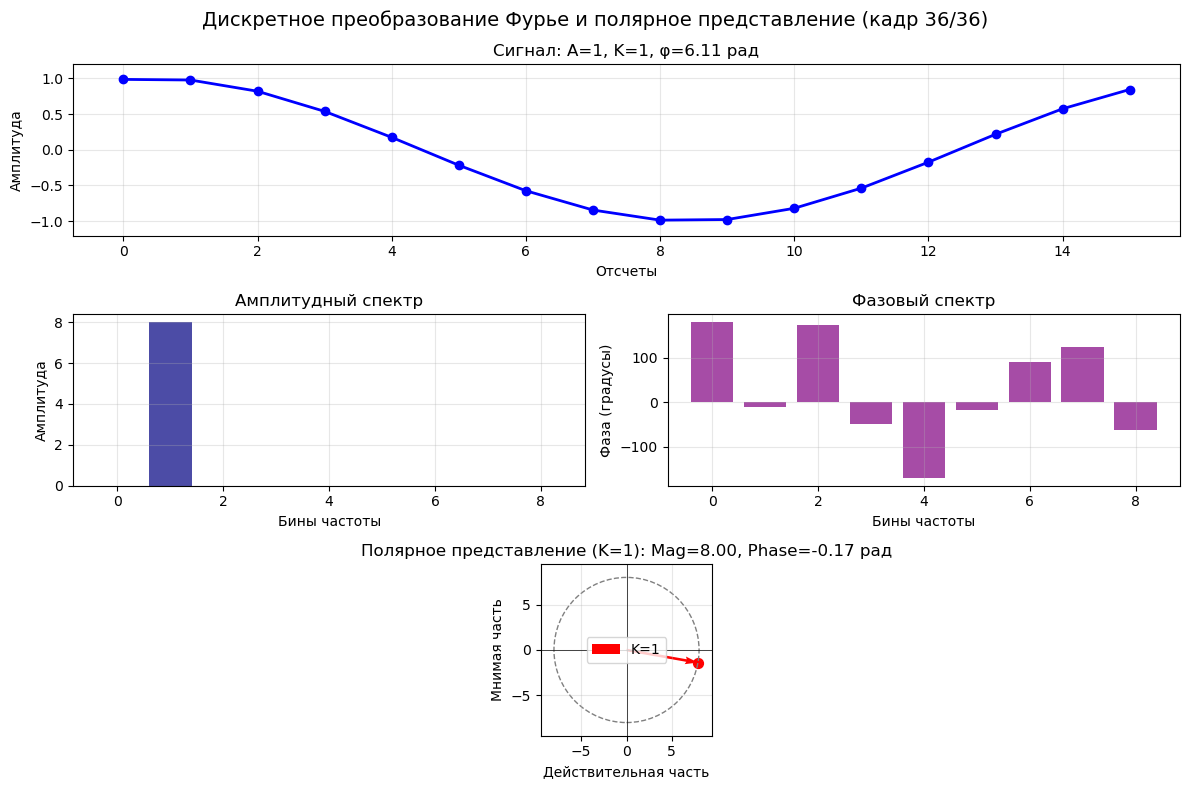

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.gridspec as gridspec

# Параметры сигнала
N = 16  # Количество отсчетов
A = 1   # Амплитуда
K = 1   # Количество периодов

# Создаем фигуру с несколькими subplots
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1])

# Создаем subplots
ax1 = fig.add_subplot(gs[0, :])  # Сигнал во временной области
ax2 = fig.add_subplot(gs[1, 0])  # Амплитудный спектр
ax3 = fig.add_subplot(gs[1, 1])  # Фазовый спектр
ax4 = fig.add_subplot(gs[2, :])  # Полярное представление

# Настраиваем внешний вид графиков
for ax in [ax1, ax2, ax3]:
    ax.grid(True, alpha=0.3)
ax4.grid(True, alpha=0.3)

# Массив отсчетов
N_i = np.arange(N)

# Функция для вычисления ДПФ
def compute_dft(signal):
    rex = np.zeros(N)
    imx = np.zeros(N)
    
    for k in range(N):
        for i in range(N):
            angle = 2 * np.pi * k * i / N
            rex[k] += signal[i] * np.cos(angle)
            imx[k] -= signal[i] * np.sin(angle)
    
    mag = np.sqrt(rex**2 + imx**2)
    phase = np.arctan2(imx, rex)
    
    # Корректировка фазы
    for i in range(len(phase)):
        if phase[i] < -np.pi:
            phase[i] += 2 * np.pi
        elif phase[i] > np.pi:
            phase[i] -= 2 * np.pi
    
    return rex, imx, mag, phase

# Функция для инициализации анимации
def init():
    ax1.clear()
    ax2.clear()
    ax3.clear()
    ax4.clear()
    
    for ax in [ax1, ax2, ax3]:
        ax.grid(True, alpha=0.3)
    ax4.grid(True, alpha=0.3)
    
    return fig,

# Функция анимации
def animate(frame):
    # Вычисляем текущую фазу (изменяется от 0 до 2π)
    phase = 2 * np.pi * frame / 36  # 36 кадров для полного цикла
    
    # Генерируем сигнал
    signal = A * np.cos(2 * np.pi * K * N_i / N + phase)
    
    # Вычисляем ДПФ
    rex, imx, mag, phase_spectrum = compute_dft(signal)
    
    # Очищаем графики
    ax1.clear()
    ax2.clear()
    ax3.clear()
    ax4.clear()
    
    # Настраиваем сетку
    for ax in [ax1, ax2, ax3]:
        ax.grid(True, alpha=0.3)
    ax4.grid(True, alpha=0.3)
    
    # График 1: Сигнал во временной области
    ax1.plot(N_i, signal, 'o-', color='blue', linewidth=2, markersize=6)
    ax1.set_title(f'Сигнал: A={A}, K={K}, φ={phase:.2f} рад', fontsize=12)
    ax1.set_xlabel('Отсчеты')
    ax1.set_ylabel('Амплитуда')
    ax1.set_ylim(-1.2*A, 1.2*A)
    
    # График 2: Амплитудный спектр
    ax2.bar(N_i[:N//2+1], mag[:N//2+1], color='navy', alpha=0.7)
    ax2.set_title('Амплитудный спектр', fontsize=12)
    ax2.set_xlabel('Бины частоты')
    ax2.set_ylabel('Амплитуда')
    
    # График 3: Фазовый спектр
    ax3.bar(N_i[:N//2+1], phase_spectrum[:N//2+1] * 180/np.pi, color='purple', alpha=0.7)
    ax3.set_title('Фазовый спектр', fontsize=12)
    ax3.set_xlabel('Бины частоты')
    ax3.set_ylabel('Фаза (градусы)')
    
    # График 4: Полярное представление
    # Показываем только первую гармонику (K=1)
    k = K
    ax4.quiver(0, 0, rex[k], imx[k], angles='xy', scale_units='xy', scale=1, 
               color='red', width=0.015, label=f'K={k}')
    ax4.scatter(rex[k], imx[k], color='red', s=50)
    
    # Добавляем окружность для масштаба
    circle = plt.Circle((0, 0), mag[k], fill=False, color='gray', linestyle='--')
    ax4.add_patch(circle)
    
    # Настраиваем полярный график
    max_val = max(np.max(np.abs(rex)), np.max(np.abs(imx))) * 1.2
    ax4.set_xlim(-max_val, max_val)
    ax4.set_ylim(-max_val, max_val)
    ax4.axhline(0, color='black', linewidth=0.5)
    ax4.axvline(0, color='black', linewidth=0.5)
    ax4.set_title(f'Полярное представление (K={k}): Mag={mag[k]:.2f}, Phase={phase_spectrum[k]:.2f} рад', fontsize=12)
    ax4.set_xlabel('Действительная часть')
    ax4.set_ylabel('Мнимая часть')
    ax4.legend()
    ax4.set_aspect('equal')
    
    # Общий заголовок
    fig.suptitle(f'Дискретное преобразование Фурье и полярное представление (кадр {frame+1}/36)', fontsize=14)
    
    plt.tight_layout()
    
    return fig,

# Создаем анимацию
ani = FuncAnimation(fig, animate, frames=36, init_func=init, blit=True, interval=200)

# Сохраняем как GIF
ani.save('dft_polar_representation.gif', writer='pillow', fps=5)

# Показываем анимацию в Jupyter notebook
HTML(ani.to_jshtml())